# Observed SB2: download, fit, inspect
**Question:** can the combined light of a real SB2 be represented by two coeval stars?

For an astronomy group meeting; basic SED and binary-star concepts are sufficient.
Allow **6 minutes**. We will load observed XP and photometry, compare single and binary fits,
and check the inferred mass ratio against a published RV orbit.

This is Gaia DR3 **858860697467058688**, not a synthetic spectrum.
Default execution uses the included public-data snapshot; online acquisition is optional.
Install `sedkit[download,notebook]` from this checkout and select its Python kernel.

In [1]:
from pathlib import Path
import sys, json, csv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path(globals().get('__file__', Path.cwd())).resolve()
if ROOT.is_file():
    ROOT = ROOT.parent
while not (ROOT / 'src' / 'sedkit').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'src' / 'sedkit').is_dir():
    raise RuntimeError('Open this notebook from the sedkit checkout.')
sys.path.insert(0, str(ROOT / 'src'))
from sedkit import SED, StellarModel, download, fit, plot
from sedkit.plot import PAPER_STYLE, BINARY, SINGLE

OUT = ROOT / 'examples' / 'group_meeting' / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
model = StellarModel()

## 1. Retrieve the observations
The public API is one `download` call. Leave the switch off during the talk;
the snapshot contains the same observed fluxes, errors and catalogue metadata.

In [2]:
SOURCE_ID = '858860697467058688'
LIVE_DOWNLOAD = False
snapshot = ROOT / 'examples' / 'sb2_20260927' / (SOURCE_ID + '.npz')
sed = (download(SOURCE_ID, cache_dir=OUT / 'cache')
       if LIVE_DOWNLOAD else SED.load(snapshot))
print(f'Gaia DR3 {sed.source_id}')
print(f'Parallax: {sed.parallax_mas:.3f} +/- {sed.parallax_error_mas:.3f} mas')
print(f'Available channels: XP={sed.mask[:61].sum()}, broadbands={sed.mask[61:66].sum()}')
print(f'Fitted channels: {sed.fit_mask().sum()} (W1/W2 held out)')

Gaia DR3 858860697467058688
Parallax: 10.977 +/- 0.015 mas
Available channels: XP=61, broadbands=5
Fitted channels: 64 (W1/W2 held out)


## 2. First look at the data
Fluxes are at the star's actual distance. XP and broadband measurements are shown
in physical units; we do not normalize the observed spectrum.

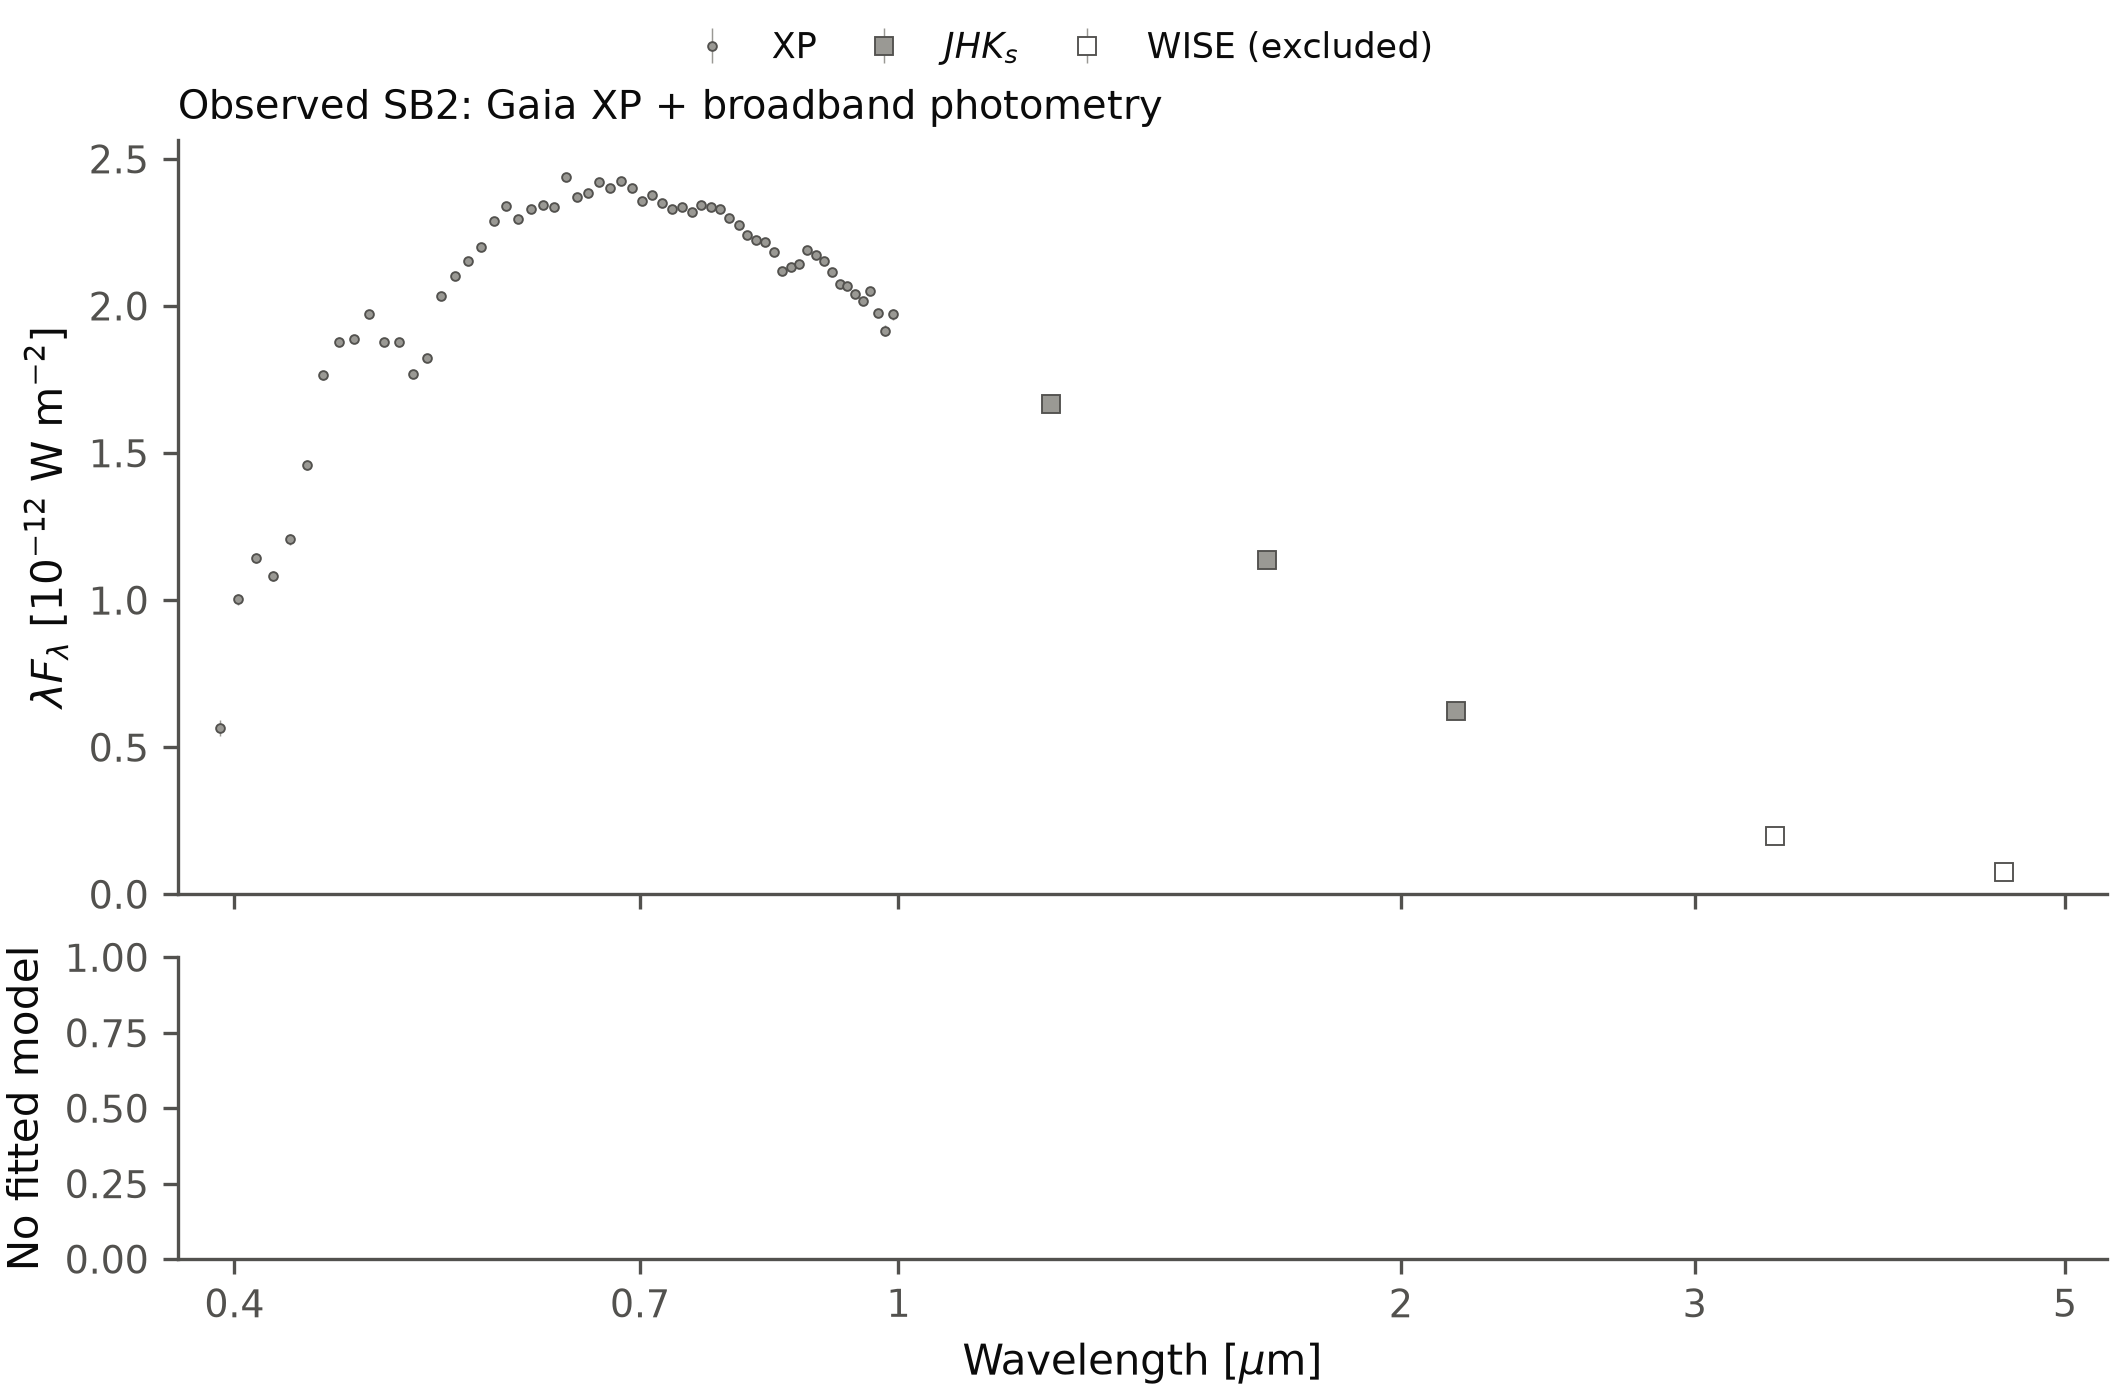

In [3]:
fig = plot(sed, title='Observed SB2: Gaia XP + broadband photometry',
           path=OUT / '01_observations.png')
plt.close(fig)
display(Image(filename=str(OUT / '01_observations.png')))

## 3. Compare single and binary models
The binary is a physical sum of two coeval stellar spectra. Both hypotheses use
the same fluxes and errors. Age and metallicity are free here; a shared catalogue
parallax constraint sets the absolute scale. Model covariance is included.

In [4]:
before = (sed.flux.copy(), sed.error.copy(), sed.mask.copy())
result = fit(sed, model=model, age_gyr=None, feh=None)
for name in ('single', 'binary'):
    r = result[name]
    print(f"{name:6s}: M1={r['m1']:.3f}, q={r['q']:.3f}, "
          f"age={r['age_gyr']:.2f} Gyr, [M/H]={r['feh']:.2f}, "
          f"chi2/N={r['chi2']/r['n_fit']:.2f}, bounds={r['at_bounds']}")
print(f"Single minus binary objective: {result['delta']:.1f}")
for original, current in zip(before, (sed.flux, sed.error, sed.mask)):
    np.testing.assert_array_equal(original, current)

single: M1=0.938, q=0.000, age=10.00 Gyr, [M/H]=0.37, chi2/N=7.91, bounds=['ln_age']
binary: M1=0.862, q=0.855, age=10.00 Gyr, [M/H]=0.08, chi2/N=1.19, bounds=['ln_age']
Single minus binary objective: 431.6


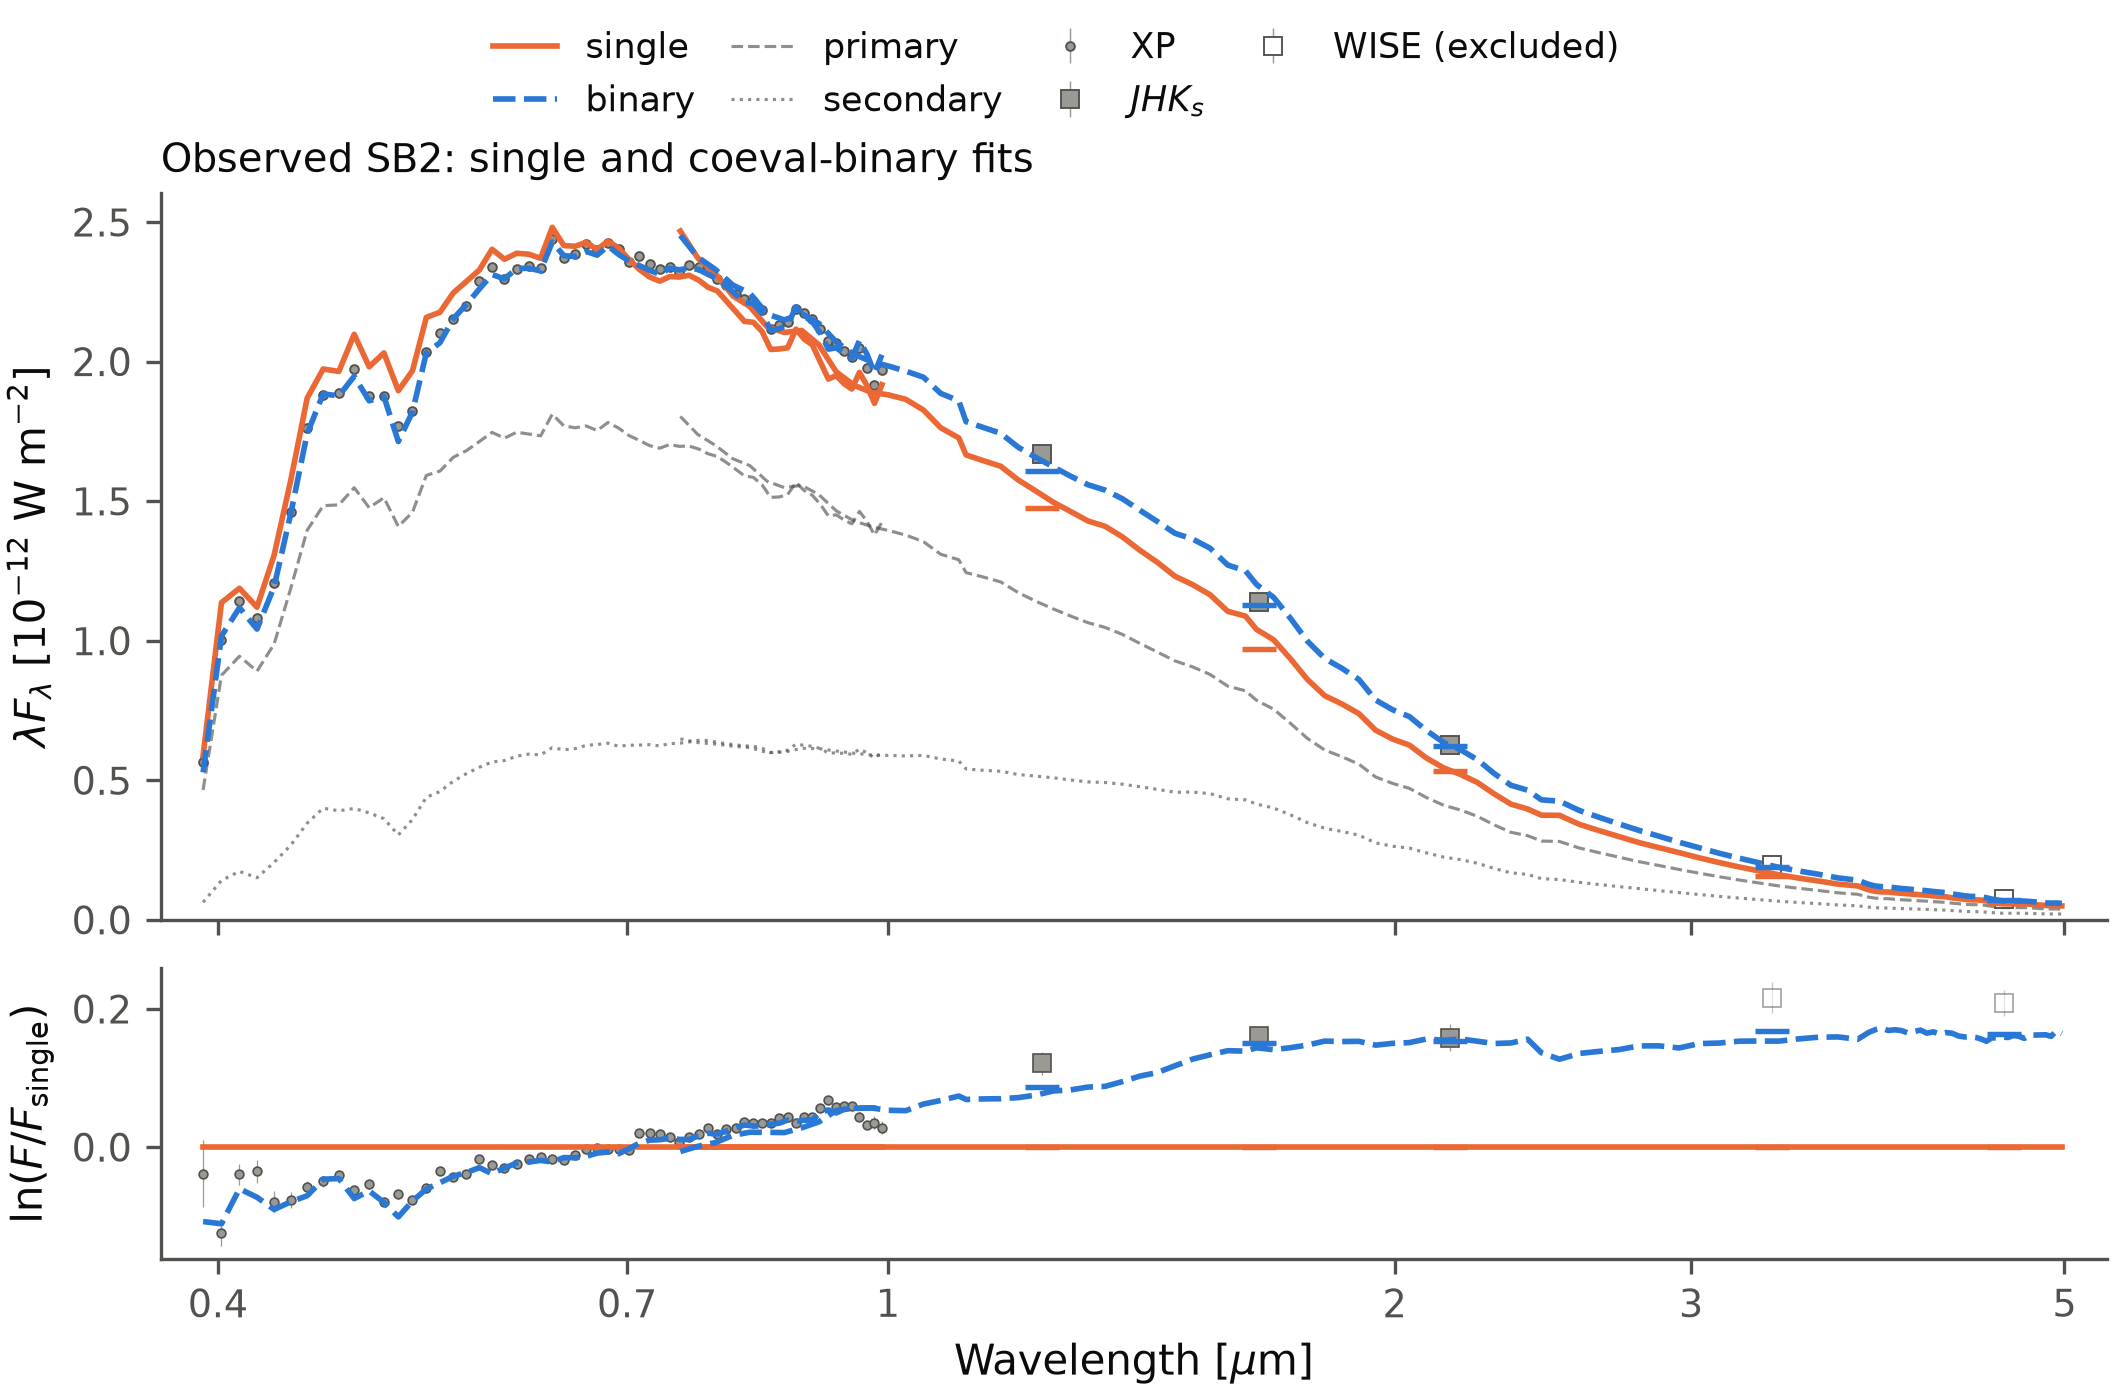

In [5]:
fig = plot(sed, result, title='Observed SB2: single and coeval-binary fits',
           path=OUT / '01_fit.png')
fig.savefig(OUT / '01_fit.pdf', bbox_inches='tight', pad_inches=.02)
plt.close(fig)
display(Image(filename=str(OUT / '01_fit.png')))

## 4. Compare with the RV mass ratio
For an SB2, q = K1/K2 (with the component convention q <= 1).
These Gaia NSS amplitudes are a comparison, not an input to the SED fit.

In [6]:
with (ROOT / 'examples' / 'sb2_20260927' / 'targets.csv').open() as stream:
    target = next(row for row in csv.DictReader(stream) if row['source_id'] == SOURCE_ID)
k1, k2 = float(target['semi_amplitude_primary']), float(target['semi_amplitude_secondary'])
q_rv = min(k1/k2, k2/k1)
print(f"q from RV = {q_rv:.4f}; q from SED = {result['binary']['q']:.4f}")

q from RV = 0.8679; q from SED = 0.8553


## What this example tells us
The binary fits better and its mass ratio is close to the independent RV ratio.
The residual panel still matters: model preference is not a binary probability,
and this one example does not measure mass accuracy or completeness.
The best age reaches the supported upper limit.

**Discussion:** what would be lost if both the data and model were normalized?
Companion luminosity would stop being absolute-flux evidence.

**Try after the talk:** fix the RV ratio and see how much the SED objective changes.

In [7]:
# Optional exercise; enable it after the presentation.
RUN_EXERCISE = False
if RUN_EXERCISE:
    fixed_q = fit(sed, kind='binary', model=model, q=q_rv, age_gyr=None, feh=None)
    print(f"Fixed-q minus free-q objective: {fixed_q['objective']-result['binary']['objective']:.2f}")

Data and selection: [observed SB2 examples](../../docs/sb2.md).
Next: [add observed SPHEREx](02_observed_spherex.ipynb).

Figure-generating code: [01_observed_sb2.py](01_observed_sb2.py).